# Inférence causale sur les intentions d'achat en ligne

## Effet exploratoire d'une session durant le weekend sur la probabilité d'achat

**Jeu de données :** Online Shoppers Purchasing Intention, UCI Machine Learning Repository  
**Unité d'analyse :** une session de navigation  
**Exposition :** `Weekend`  
**Résultat :** `Revenue`  
**Date :** juillet 2026

Ce notebook présente une analyse causale complète : formulation de la question, connaissances préalables, graphe causal, découverte causale exploratoire, identification, estimation, robustesse et limites.

## 1. Formulation du problème

Le commerce électronique cherche souvent à comprendre pourquoi certaines visites se terminent par un achat. Le jeu de données utilisé contient des informations sur 12 330 sessions observées sur un site de commerce électronique pendant une année. Chaque session appartient à un utilisateur différent dans la construction du jeu UCI.

La question causale retenue est :

> Parmi les sessions hors proximité d'un jour commercial spécial, quel serait l'effet moyen du fait qu'une session ait lieu durant le weekend plutôt qu'en semaine sur la probabilité qu'elle se termine par un achat ?

Cette question est différente d'une question prédictive. Il ne s'agit pas de prévoir `Revenue`, mais de comparer deux situations hypothétiques pour des sessions comparables.

L'intervention reste théorique : déplacer une session existante vers le weekend, à l'intérieur du même mois, en conservant son profil pré-session et son canal d'acquisition. L'analyse ne mesure donc pas l'effet du weekend sur le nombre de visiteurs ou le chiffre d'affaires total du site.

## 2. Données, provenance et reproductibilité

Le fichier provient du **UCI Machine Learning Repository**, dataset no 468, DOI `10.24432/C5F88Q`. La copie locale est vérifiée par son empreinte SHA-256. Le résultat `Revenue` indique une transaction, et non un montant monétaire ni une intention psychologique déclarée.

In [1]:
from pathlib import Path
import contextlib
import hashlib
import io
import platform
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from causallearn.graph.GraphNode import GraphNode
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge

SEED = 20260715
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def trouver_racine(depart: Path) -> Path:
    depart = depart.resolve()
    for candidat in (depart, *depart.parents):
        chemin = candidat / "02_data" / "raw" / "online_shoppers_intention.csv"
        if chemin.exists():
            return candidat
    raise FileNotFoundError("La racine du projet ou le CSV brut est introuvable.")


RACINE = trouver_racine(Path.cwd())
CHEMIN_DONNEES = RACINE / "02_data" / "raw" / "online_shoppers_intention.csv"
DOSSIER_FIGURES = RACINE / "04_outputs" / "figures"
DOSSIER_TABLEAUX = RACINE / "04_outputs" / "tableaux"
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)
DOSSIER_TABLEAUX.mkdir(parents=True, exist_ok=True)

EMPREINTE_ATTENDUE = "b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9"
empreinte = hashlib.sha256(CHEMIN_DONNEES.read_bytes()).hexdigest()
assert empreinte == EMPREINTE_ATTENDUE, "Le fichier ne correspond pas à la copie UCI vérifiée."

print(f"Python : {platform.python_version()}")
print(f"pandas : {pd.__version__}")
print(f"Fichier : {CHEMIN_DONNEES}")
print(f"SHA-256 : {empreinte}")

Python : 3.14.3
pandas : 3.0.3
Fichier : C:\Users\Tazi\Desktop\School\Projet\projet_ml_causalite_agent\02_data\raw\online_shoppers_intention.csv
SHA-256 : b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9


In [2]:
df = pd.read_csv(CHEMIN_DONNEES)

assert df.shape == (12_330, 18)
assert df.columns.is_unique
assert df.isna().sum().sum() == 0
assert set(df["Weekend"].unique()) == {False, True}
assert set(df["Revenue"].unique()) == {False, True}

controle_donnees = pd.DataFrame(
    {
        "Indicateur": [
            "Sessions",
            "Variables explicatives",
            "Valeurs manquantes",
            "Lignes exactement identiques",
            "Achats",
            "Taux d'achat",
        ],
        "Valeur": [
            len(df),
            17,
            int(df.isna().sum().sum()),
            int(df.duplicated().sum()),
            int(df["Revenue"].sum()),
            f"{100 * df['Revenue'].mean():.2f} %",
        ],
    }
)
display(controle_donnees)

,Indicateur,Valeur
0,Sessions,12330
1,Variables explicatives,17
2,Valeurs manquantes,0
3,Lignes exactement identiques,125
4,Achats,1908
5,Taux d'achat,15.47 %


### 2.1 Variables principales et ordre temporel

| Groupe | Variables | Utilisation causale |
|---|---|---|
| Calendrier | `Month`, `SpecialDay`, `Weekend` | contexte et exposition |
| Profil pré-session | `VisitorType`, `Region`, `OperatingSystems`, `Browser` | ajustement |
| Acquisition | `TrafficType` | ajustement principal, rôle discuté en sensibilité |
| Navigation | nombres de pages, durées, `BounceRates`, `ExitRates` | exclues : médiateurs ou variables post-traitement possibles |
| Valeur de page | `PageValues` | exclue : construction liée aux transactions et risque de fuite |
| Résultat | `Revenue` | achat binaire (Y) |

Le choix des covariables repose sur leur rôle causal supposé, et non sur leur corrélation avec `Revenue`.

## 3. Description de l'échantillon et définition de la population cible

Les valeurs brutes de `SpecialDay` présentent un défaut de recouvrement : certaines n'apparaissent qu'en semaine et la valeur 1 uniquement le weekend. L'analyse principale est donc restreinte aux sessions avec `SpecialDay=0`. Cela définit un estimand plus étroit, mais évite de comparer des situations absentes des données.

In [3]:
recouvrement_special_day = pd.crosstab(
    df["SpecialDay"], df["Weekend"]
).rename(columns={False: "Semaine", True: "Weekend"})

df_analyse = df.loc[df["SpecialDay"].eq(0)].copy().reset_index(drop=True)

resume_groupes = (
    df_analyse.groupby("Weekend")["Revenue"]
    .agg(Sessions="size", Achats="sum", Taux_achat="mean")
    .rename(index={False: "Semaine", True: "Weekend"})
)
resume_groupes["Taux_achat_pct"] = 100 * resume_groupes["Taux_achat"]

display(recouvrement_special_day)
display(resume_groupes[["Sessions", "Achats", "Taux_achat_pct"]].round(2))

assert len(df_analyse) == 11_079
assert resume_groupes.loc["Semaine", "Sessions"] == 8_371
assert resume_groupes.loc["Weekend", "Sessions"] == 2_708

Weekend,Semaine,Weekend
SpecialDay,,
0.0,8371,2708
0.2,178,0
0.4,243,0
0.6,351,0
0.8,319,6
1.0,0,154


,Sessions,Achats,Taux_achat_pct
Weekend,,,
Semaine,8371,1342,16.03
Weekend,2708,489,18.06


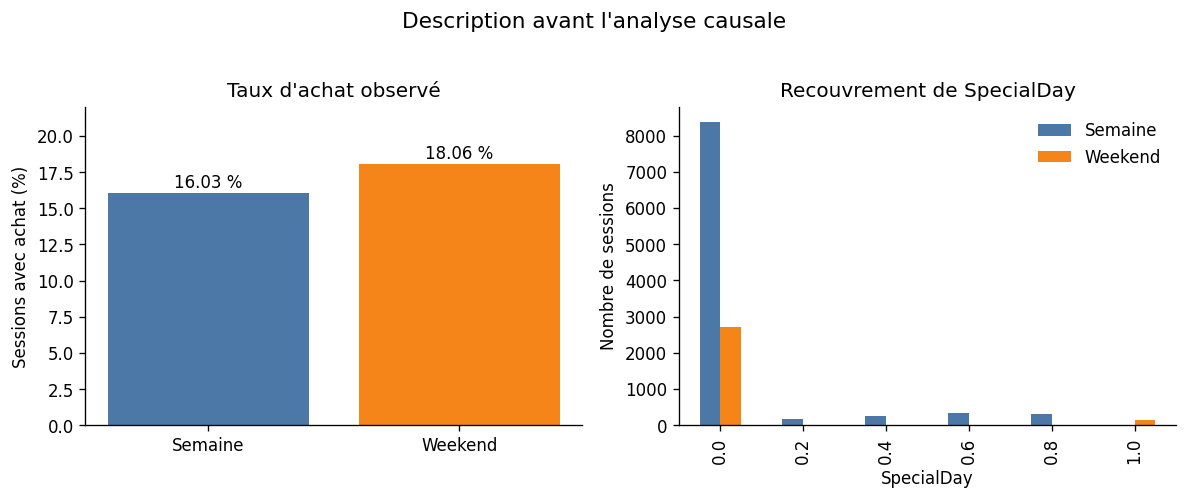

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    resume_groupes.index,
    resume_groupes["Taux_achat_pct"],
    color=["#4C78A8", "#F58518"],
)
axes[0].set_title("Taux d'achat observé")
axes[0].set_ylabel("Sessions avec achat (%)")
axes[0].set_ylim(0, 22)
for i, valeur in enumerate(resume_groupes["Taux_achat_pct"]):
    axes[0].text(i, valeur + 0.4, f"{valeur:.2f} %", ha="center")

recouvrement_special_day.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Recouvrement de SpecialDay")
axes[1].set_xlabel("SpecialDay")
axes[1].set_ylabel("Nombre de sessions")
axes[1].legend(frameon=False)

fig.suptitle("Description avant l'analyse causale", y=1.03, fontsize=13)
fig.tight_layout()
chemin = DOSSIER_FIGURES / "01_description_et_recouvrement.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

Dans la population d'analyse, le taux observé est de **18,06 %** le weekend et de **16,03 %** en semaine. L'écart brut est donc de **2,03 points de pourcentage**. Il s'agit uniquement d'une association : les deux groupes ne sont pas randomisés.

## 4. Connaissances préalables et DAG de travail

Le DAG est construit à partir de l'ordre temporel et du fonctionnement plausible d'une session de commerce électronique. Les caractéristiques du visiteur, le calendrier et le canal d'acquisition précèdent la navigation. Les mesures de navigation peuvent être influencées par `Weekend` et conduire à `Revenue`; elles ne doivent donc pas être ajustées lorsqu'on vise l'effet total.

Le graphe fait également apparaître deux causes non observées plausibles : les promotions/prix et l'intention d'achat préalable. Elles rappellent que l'absence de confusion non mesurée est une hypothèse forte.

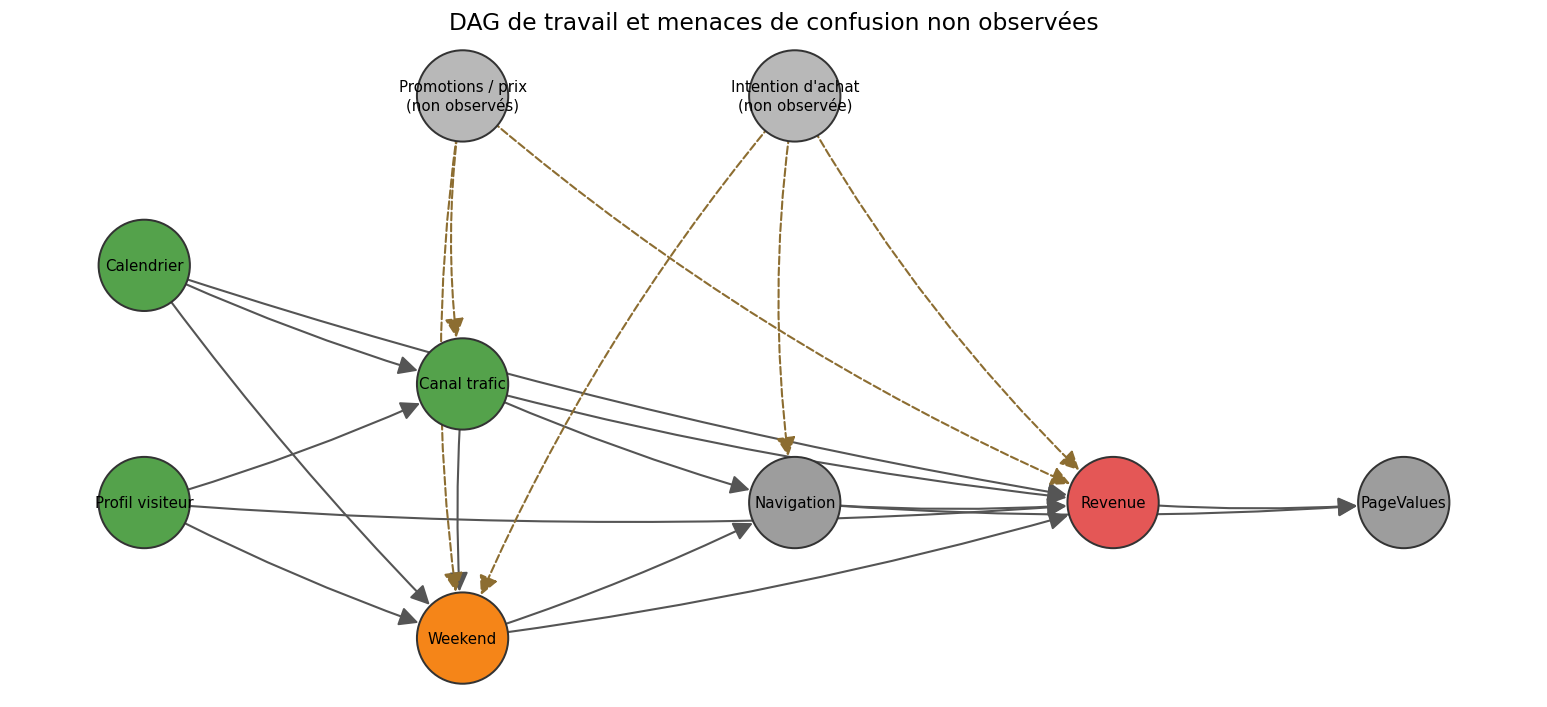

In [5]:
noeuds_observes = {
    "Calendrier": (0, 3.2),
    "Profil visiteur": (0, 1.8),
    "Canal trafic": (2.3, 2.5),
    "Weekend": (2.3, 1.0),
    "Navigation": (4.7, 1.8),
    "Revenue": (7.0, 1.8),
    "PageValues": (9.1, 1.8),
}
noeuds_latents = {
    "Promotions / prix\n(non observés)": (2.3, 4.2),
    "Intention d'achat\n(non observée)": (4.7, 4.2),
}
positions = {**noeuds_observes, **noeuds_latents}

aretes_observees = [
    ("Calendrier", "Canal trafic"),
    ("Calendrier", "Weekend"),
    ("Calendrier", "Revenue"),
    ("Profil visiteur", "Canal trafic"),
    ("Profil visiteur", "Weekend"),
    ("Profil visiteur", "Revenue"),
    ("Canal trafic", "Weekend"),
    ("Canal trafic", "Navigation"),
    ("Canal trafic", "Revenue"),
    ("Weekend", "Navigation"),
    ("Weekend", "Revenue"),
    ("Navigation", "Revenue"),
    ("Navigation", "PageValues"),
    ("Revenue", "PageValues"),
]
aretes_latentes = [
    ("Promotions / prix\n(non observés)", "Weekend"),
    ("Promotions / prix\n(non observés)", "Canal trafic"),
    ("Promotions / prix\n(non observés)", "Revenue"),
    ("Intention d'achat\n(non observée)", "Weekend"),
    ("Intention d'achat\n(non observée)", "Navigation"),
    ("Intention d'achat\n(non observée)", "Revenue"),
]

graphe_domaine = nx.DiGraph()
graphe_domaine.add_nodes_from(positions)
graphe_domaine.add_edges_from(aretes_observees + aretes_latentes)

fig, ax = plt.subplots(figsize=(13, 6))
couleurs = []
for n in graphe_domaine.nodes:
    if n == "Weekend":
        couleurs.append("#F58518")
    elif n == "Revenue":
        couleurs.append("#E45756")
    elif n in noeuds_latents:
        couleurs.append("#B8B8B8")
    elif n in {"Navigation", "PageValues"}:
        couleurs.append("#9D9D9D")
    else:
        couleurs.append("#54A24B")

nx.draw_networkx_nodes(
    graphe_domaine, positions, node_color=couleurs, node_size=3000,
    edgecolors="#333333", linewidths=1.2, ax=ax
)
nx.draw_networkx_labels(graphe_domaine, positions, font_size=9, ax=ax)
nx.draw_networkx_edges(
    graphe_domaine, positions, edgelist=aretes_observees,
    arrows=True, arrowstyle="-|>", arrowsize=24, width=1.25,
    edge_color="#555555", connectionstyle="arc3,rad=0.04",
    min_source_margin=24, min_target_margin=28, ax=ax
)
nx.draw_networkx_edges(
    graphe_domaine, positions, edgelist=aretes_latentes,
    arrows=True, arrowstyle="-|>", arrowsize=24, width=1.25,
    style="dashed", edge_color="#8C6D31", connectionstyle="arc3,rad=0.08",
    min_source_margin=24, min_target_margin=28, ax=ax
)
ax.set_title("DAG de travail et menaces de confusion non observées", fontsize=14)
ax.axis("off")
fig.tight_layout()
chemin = DOSSIER_FIGURES / "02_dag_de_travail.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

### 4.1 Ensemble d'ajustement principal

Sous le DAG observé, l'ensemble retenu est :

\[
Z = \{Month, VisitorType, Region, OperatingSystems, Browser, TrafficType\}.
\]

`TrafficType` est supposée fixée avant l'exposition dans l'analyse principale. Si le weekend modifie plutôt le canal d'arrivée, cette variable devient un médiateur; une analyse sans `TrafficType` est donc présentée plus loin.

Les chemins passant par les promotions, les prix ou l'intention non observée ne peuvent pas être bloqués avec les données disponibles. Le DAG ne prouve donc pas l'identification; il explicite les hypothèses nécessaires.

## 5. Découverte causale exploratoire

Le DAG n'est pas entièrement connu. Une analyse FCI est utilisée comme vérification exploratoire, car FCI autorise la présence de confondeurs latents et renvoie un PAG, c'est-à-dire un graphe partiellement orienté.

Pour rendre les tests conditionnels discrets plus stables, l'analyse utilise six variables pré-session ou de résultat : période de l'année, proximité d'un jour spécial, nouveau visiteur, source de trafic regroupée, weekend et achat. Un test (G^2), un seuil de 1 % et des contraintes temporelles sont utilisés.

In [6]:
regroupement_periode = {
    "Feb": "P1", "Mar": "P1",
    "May": "P2", "June": "P2",
    "Jul": "P3", "Aug": "P3", "Sep": "P3",
    "Oct": "P4", "Nov": "P4", "Dec": "P4",
}

donnees_decouverte = pd.DataFrame({
    "Periode": df["Month"].map(regroupement_periode),
    "JourSpecial": np.where(df["SpecialDay"].gt(0), "oui", "non"),
    "NouveauVisiteur": np.where(
        df["VisitorType"].eq("New_Visitor"), "oui", "non"
    ),
    "SourceTrafic": df["TrafficType"].map(
        lambda v: str(v) if v in {1, 2, 3} else "autres"
    ),
    "Weekend": np.where(df["Weekend"], "oui", "non"),
    "Revenue": np.where(df["Revenue"], "oui", "non"),
})

noms_decouverte = list(donnees_decouverte.columns)
matrice_discrete = np.column_stack([
    pd.factorize(donnees_decouverte[c], sort=True)[0]
    for c in noms_decouverte
])


def connaissances_temporelles():
    bk = BackgroundKnowledge()
    tiers = [
        ["Periode", "JourSpecial", "NouveauVisiteur"],
        ["SourceTrafic", "Weekend"],
        ["Revenue"],
    ]
    for niveau, noms in enumerate(tiers):
        for nom in noms:
            bk.add_node_to_tier(GraphNode(nom), niveau)
    return bk


def lancer_fci(alpha=0.01):
    with contextlib.redirect_stdout(io.StringIO()):
        graphe, _ = fci(
            matrice_discrete,
            independence_test_method="gsq",
            alpha=alpha,
            depth=2,
            max_path_length=3,
            background_knowledge=connaissances_temporelles(),
            show_progress=False,
            node_names=noms_decouverte,
        )
    return graphe


pag = lancer_fci(alpha=0.01)
aretes_pag = pag.get_graph_edges()
table_pag = pd.DataFrame({"Arête du PAG": [str(a) for a in aretes_pag]})

stabilite_fci = []
for alpha in [0.001, 0.01, 0.05]:
    g = lancer_fci(alpha)
    aretes = g.get_graph_edges()
    adjacency_w_y = any(
        {a.get_node1().get_name(), a.get_node2().get_name()}
        == {"Weekend", "Revenue"}
        for a in aretes
    )
    voisins_weekend = sorted({
        autre
        for a in aretes
        for autre in [
            a.get_node2().get_name()
            if a.get_node1().get_name() == "Weekend"
            else a.get_node1().get_name()
            if a.get_node2().get_name() == "Weekend"
            else None
        ]
        if autre is not None
    })
    stabilite_fci.append({
        "alpha": alpha,
        "Nombre d'arêtes": len(aretes),
        "Adjacence Weekend-Revenue": adjacency_w_y,
        "Voisins de Weekend": ", ".join(voisins_weekend),
    })

stabilite_fci = pd.DataFrame(stabilite_fci)
display(table_pag)
display(stabilite_fci)

table_pag.to_csv(DOSSIER_TABLEAUX / "01_aretes_pag_fci.csv", index=False)

,Arête du PAG
0,Periode o-o JourSpecial
1,Periode o-o NouveauVisiteur
2,Periode --> SourceTrafic
3,Periode --> Revenue
4,JourSpecial o-o NouveauVisiteur
5,JourSpecial --> SourceTrafic
6,JourSpecial --> Weekend
7,JourSpecial --> Revenue
8,NouveauVisiteur --> SourceTrafic
9,NouveauVisiteur --> Weekend


,alpha,Nombre d'arêtes,Adjacence Weekend-Revenue,Voisins de Weekend
0,0.001,12,False,"JourSpecial, SourceTrafic"
1,0.010,13,False,"JourSpecial, NouveauVisiteur, SourceTrafic"
2,0.050,13,False,"JourSpecial, NouveauVisiteur, SourceTrafic"


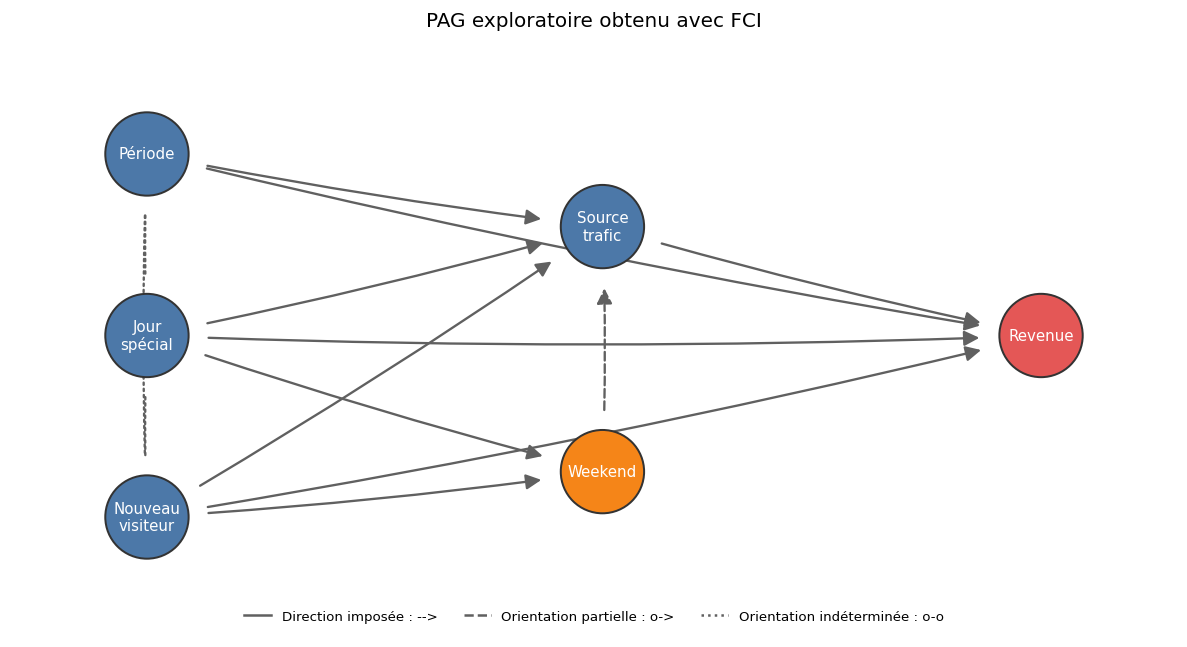

In [7]:
positions_pag = {
    "Periode": (0, 3.0),
    "JourSpecial": (0, 2.0),
    "NouveauVisiteur": (0, 1.0),
    "SourceTrafic": (2.7, 2.6),
    "Weekend": (2.7, 1.25),
    "Revenue": (5.3, 2.0),
}
libelles_pag = {
    "Periode": "Période",
    "JourSpecial": "Jour\nspécial",
    "NouveauVisiteur": "Nouveau\nvisiteur",
    "SourceTrafic": "Source\ntrafic",
    "Weekend": "Weekend",
    "Revenue": "Revenue",
}

fig, ax = plt.subplots(figsize=(10, 5.5))
g_visuel = nx.Graph()
g_visuel.add_nodes_from(positions_pag)
couleurs_pag = [
    "#F58518" if n == "Weekend"
    else "#E45756" if n == "Revenue"
    else "#4C78A8"
    for n in g_visuel.nodes
]
nx.draw_networkx_nodes(
    g_visuel, positions_pag, node_color=couleurs_pag, node_size=2500,
    edgecolors="#333333", linewidths=1.2, ax=ax
)
nx.draw_networkx_labels(
    g_visuel, positions_pag, labels=libelles_pag,
    font_size=9, font_color="white", ax=ax
)

for a in aretes_pag:
    u = a.get_node1().get_name()
    v = a.get_node2().get_name()
    relation = str(a)
    if "-->" in relation:
        style_fleche, style_ligne = "-|>", "solid"
    elif "o->" in relation:
        style_fleche, style_ligne = "-|>", "dashed"
    else:
        style_fleche, style_ligne = "-", "dotted"
    fleche = FancyArrowPatch(
        positions_pag[u], positions_pag[v],
        arrowstyle=style_fleche,
        mutation_scale=19,
        linewidth=1.4,
        linestyle=style_ligne,
        color="#606060",
        shrinkA=37,
        shrinkB=37,
        connectionstyle="arc3,rad=0.02",
        zorder=1,
    )
    ax.add_patch(fleche)

ax.plot([], [], color="#606060", linestyle="solid", label="Direction imposée : -->")
ax.plot([], [], color="#606060", linestyle="dashed", label="Orientation partielle : o->")
ax.plot([], [], color="#606060", linestyle="dotted", label="Orientation indéterminée : o-o")
ax.legend(loc="lower center", ncol=3, frameon=False, fontsize=8)
ax.set_title("PAG exploratoire obtenu avec FCI")
ax.set_xlim(-0.8, 6.1)
ax.set_ylim(0.35, 3.65)
ax.axis("off")
fig.tight_layout()
chemin = DOSSIER_FIGURES / "03_pag_fci.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

Le PAG ne contient pas d'adjacence entre `Weekend` et `Revenue`, et cette absence reste présente pour les seuils 0,1 %, 1 % et 5 %. L'association marginale peut donc être expliquée par des variables de contexte mesurées dans cette représentation.

Ce résultat ne prouve pas un effet nul. La discrétisation, les regroupements, les hypothèses de Markov et de fidélité, les erreurs de mesure et le faible effet éventuel peuvent faire disparaître une arête. La découverte causale complète le DAG de domaine mais ne le remplace pas.

## 6. Cadre causal, estimand et hypothèses

Le cadre principal combine les résultats potentiels et le DAG de Pearl.

- $T=1$ : session durant le weekend ;
- $T=0$ : session en semaine ;
- $Y(1)$ et $Y(0)$ : résultats potentiels d'une même session sous les deux expositions ;
- $Y$ : transaction observée.

Dans la population avec `SpecialDay=0`, l'estimand est :

\[
\tau_0 = E[Y(1)-Y(0) \mid SpecialDay=0].
\]

Comme $Y$ est binaire, $\tau_0$ est une différence moyenne de probabilité d'achat.

### Hypothèses d'identification

1. **Consistance** : `Weekend` correspond à une intervention suffisamment bien définie.
2. **Échangeabilité conditionnelle** : $(Y(1),Y(0)) \perp T \mid Z$.
3. **Positivité** : les deux expositions existent dans les profils comparés.
4. **Absence d'interférence** : une session ne modifie pas le résultat potentiel d'une autre.
5. **Mesure correcte et ordre temporel valide** des covariables.

L'échangeabilité n'est pas vérifiable. Les promotions, prix, produits, campagnes et intentions préalables sont absents; l'identification reste donc conditionnelle à une hypothèse forte d'absence de confusion résiduelle.

## 7. Stratégie d'identification

Sous le DAG observé, l'ajustement backdoor utilise $Z$ :

\[
P(Y=1\mid do(T=t), SpecialDay=0)
= \sum_z P(Y=1\mid T=t,Z=z,SpecialDay=0)P(Z=z\mid SpecialDay=0).
\]

Les variables de navigation ne sont pas incluses dans $Z$, car elles peuvent se situer après `Weekend`. Les ajuster bloquerait une partie de l'effet total ou pourrait ouvrir un chemin par collider.

En présence des causes latentes du DAG, aucun ensemble entièrement observé ne garantit l'identification. Les estimations suivantes sont donc interprétées comme **estimations causales exploratoires sous hypothèses**, et non comme preuve expérimentale.

## 8. Méthodes d'estimation

Quatre estimations sont comparées :

1. différence brute de taux ;
2. standardisation par régression logistique ;
3. pondération IPW de Hájek par le score de propension ;
4. estimateur AIPW doublement robuste, retenu comme résultat principal.

Les modèles du traitement et du résultat utilisent une régression logistique avec encodage one-hot. Les prédictions sont obtenues par validation croisée en cinq plis afin de limiter le biais de surapprentissage. Les modalités comptant moins de 20 observations sont regroupées par l'encodeur.

In [8]:
COVARIABLES_CATEGORIELLES = [
    "Month",
    "VisitorType",
    "Region",
    "OperatingSystems",
    "Browser",
    "TrafficType",
]


def construire_pipeline(categorielle, binaire, modele="logit", seed=SEED):
    pretraitement = ColumnTransformer([
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20,
                drop="first",
            ),
            categorielle,
        ),
        ("bin", "passthrough", binaire),
    ])
    if modele == "logit":
        estimateur = LogisticRegression(max_iter=2_000, solver="lbfgs")
    elif modele == "foret":
        estimateur = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=50,
            max_features="sqrt",
            n_jobs=-1,
            random_state=seed,
        )
    else:
        raise ValueError("Modèle de nuisance inconnu.")
    return Pipeline([("pretraitement", pretraitement), ("modele", estimateur)])


def predictions_croisees(
    donnees,
    covariables_categorielles,
    covariables_binaires=(),
    modele="logit",
):
    d = donnees.copy().reset_index(drop=True)
    cat = list(covariables_categorielles)
    binaires = list(covariables_binaires)
    for variable in cat:
        d[variable] = d[variable].astype(str)

    t = d["Weekend"].astype(int).to_numpy()
    y = d["Revenue"].astype(int).to_numpy()
    x_t = d[cat + binaires].copy()
    x_y = d[cat + binaires + ["Weekend"]].copy()
    x_y["Weekend"] = t

    e = np.zeros(len(d))
    m1 = np.zeros(len(d))
    m0 = np.zeros(len(d))

    strates = 2 * t + y
    plis = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    for numero, (entrainement, test) in enumerate(plis.split(x_t, strates)):
        modele_t = construire_pipeline(cat, binaires, modele, SEED + numero)
        modele_t.fit(x_t.iloc[entrainement], t[entrainement])
        e[test] = modele_t.predict_proba(x_t.iloc[test])[:, 1]

        modele_y = construire_pipeline(
            cat, binaires + ["Weekend"], modele, SEED + 100 + numero
        )
        modele_y.fit(x_y.iloc[entrainement], y[entrainement])
        x1 = x_y.iloc[test].copy()
        x0 = x_y.iloc[test].copy()
        x1["Weekend"] = 1
        x0["Weekend"] = 0
        m1[test] = modele_y.predict_proba(x1)[:, 1]
        m0[test] = modele_y.predict_proba(x0)[:, 1]

    e = np.clip(e, 0.01, 0.99)
    return {"donnees": d, "T": t, "Y": y, "e": e, "m1": m1, "m0": m0}


def resumer_estimations(predictions):
    t = predictions["T"]
    y = predictions["Y"]
    e = predictions["e"]
    m1 = predictions["m1"]
    m0 = predictions["m0"]
    n = len(y)

    p1 = y[t == 1].mean()
    p0 = y[t == 0].mean()
    brut = p1 - p0
    se_brut = np.sqrt(
        p1 * (1 - p1) / t.sum()
        + p0 * (1 - p0) / (1 - t).sum()
    )

    gcomp = np.mean(m1 - m0)

    q1 = t / e
    q0 = (1 - t) / (1 - e)
    mu1_ipw = np.sum(q1 * y) / np.sum(q1)
    mu0_ipw = np.sum(q0 * y) / np.sum(q0)
    ipw = mu1_ipw - mu0_ipw
    influence_ipw = (
        q1 * (y - mu1_ipw) / q1.mean()
        - q0 * (y - mu0_ipw) / q0.mean()
    )
    se_ipw = influence_ipw.std(ddof=1) / np.sqrt(n)

    pseudo1 = m1 + t * (y - m1) / e
    pseudo0 = m0 + (1 - t) * (y - m0) / (1 - e)
    pseudo_aipw = pseudo1 - pseudo0
    aipw = pseudo_aipw.mean()
    se_aipw = pseudo_aipw.std(ddof=1) / np.sqrt(n)

    return {
        "Brute": (brut, brut - 1.96 * se_brut, brut + 1.96 * se_brut),
        "Standardisation": (gcomp, np.nan, np.nan),
        "IPW": (ipw, ipw - 1.96 * se_ipw, ipw + 1.96 * se_ipw),
        "AIPW": (aipw, aipw - 1.96 * se_aipw, aipw + 1.96 * se_aipw),
        "mu1_aipw": pseudo1.mean(),
        "mu0_aipw": pseudo0.mean(),
        "pseudo_aipw": pseudo_aipw,
    }

In [9]:
predictions_principales = predictions_croisees(
    df_analyse,
    COVARIABLES_CATEGORIELLES,
)
resume_estimation = resumer_estimations(predictions_principales)


def bootstrap_standardisation(donnees, repetitions=500):
    d = donnees.copy().reset_index(drop=True)
    for variable in COVARIABLES_CATEGORIELLES:
        d[variable] = d[variable].astype(str)
    x = d[COVARIABLES_CATEGORIELLES + ["Weekend"]].copy()
    x["Weekend"] = d["Weekend"].astype(int)
    y = d["Revenue"].astype(int).to_numpy()
    n = len(d)
    rng = np.random.default_rng(SEED)
    estimations = np.zeros(repetitions)

    for b in range(repetitions):
        indices = rng.integers(0, n, n)
        xb = x.iloc[indices].copy()
        yb = y[indices]
        modele = construire_pipeline(
            COVARIABLES_CATEGORIELLES, ["Weekend"], "logit", SEED + b
        )
        modele.fit(xb, yb)
        x1 = xb.copy()
        x0 = xb.copy()
        x1["Weekend"] = 1
        x0["Weekend"] = 0
        estimations[b] = np.mean(
            modele.predict_proba(x1)[:, 1]
            - modele.predict_proba(x0)[:, 1]
        )
    return estimations


bootstrap_gcomp = bootstrap_standardisation(df_analyse, repetitions=500)
resume_estimation["Standardisation"] = (
    resume_estimation["Standardisation"][0],
    np.quantile(bootstrap_gcomp, 0.025),
    np.quantile(bootstrap_gcomp, 0.975),
)

resultats_principaux = pd.DataFrame([
    {
        "Méthode": methode,
        "Estimation (points)": 100 * valeurs[0],
        "IC 95 % bas": 100 * valeurs[1],
        "IC 95 % haut": 100 * valeurs[2],
    }
    for methode, valeurs in resume_estimation.items()
    if methode in {"Brute", "Standardisation", "IPW", "AIPW"}
])

display(resultats_principaux.round(3))
resultats_principaux.to_csv(
    DOSSIER_TABLEAUX / "02_estimations_principales.csv", index=False
)

,Méthode,Estimation (points),IC 95 % bas,IC 95 % haut
0,Brute,2.026,0.378,3.674
1,Standardisation,1.384,-0.317,2.984
2,IPW,1.444,-0.256,3.143
3,AIPW,1.506,-0.176,3.188


## 9. Diagnostics du score de propension

La validité de l'IPW et de l'AIPW exige un recouvrement suffisant. Le score de propension estime ici la probabilité conditionnelle qu'une session ait lieu le weekend selon les covariables pré-session.

,Indicateur,Valeur
0,Score minimal,0.048
1,Score médian,0.229
2,Score maximal,0.919
3,"Scores hors [0,05 ; 0,95]",9.000
4,Poids stabilisé maximal,7.274
5,ESS semaine,8181.525
6,ESS weekend,2411.922


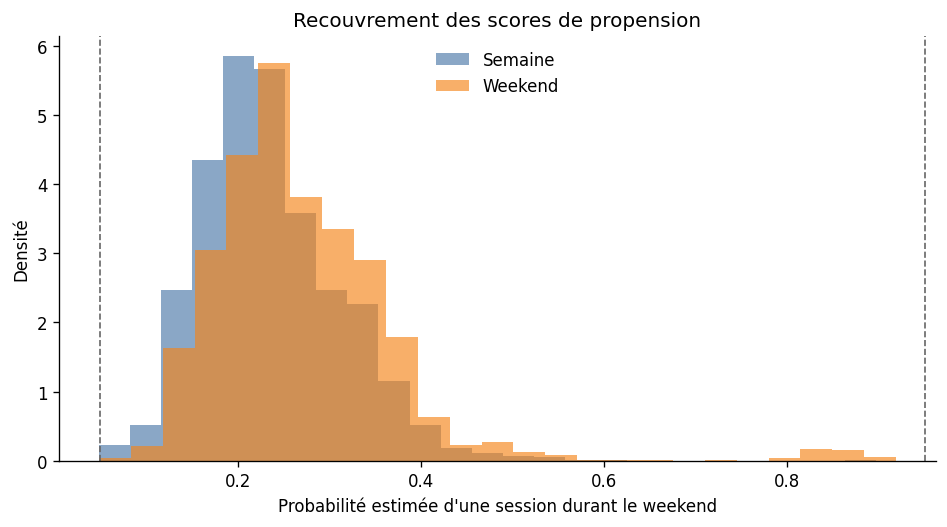

In [10]:
t = predictions_principales["T"]
e = predictions_principales["e"]
prevalence = t.mean()
poids_stabilises = np.where(
    t == 1, prevalence / e, (1 - prevalence) / (1 - e)
)


def taille_effective(poids):
    return poids.sum() ** 2 / np.sum(poids ** 2)


diagnostics_propension = pd.DataFrame({
    "Indicateur": [
        "Score minimal",
        "Score médian",
        "Score maximal",
        "Scores hors [0,05 ; 0,95]",
        "Poids stabilisé maximal",
        "ESS semaine",
        "ESS weekend",
    ],
    "Valeur": [
        e.min(),
        np.median(e),
        e.max(),
        int(((e < 0.05) | (e > 0.95)).sum()),
        poids_stabilises.max(),
        taille_effective(poids_stabilises[t == 0]),
        taille_effective(poids_stabilises[t == 1]),
    ],
})
display(diagnostics_propension.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(e[t == 0], bins=25, alpha=0.65, density=True, label="Semaine", color="#4C78A8")
ax.hist(e[t == 1], bins=25, alpha=0.65, density=True, label="Weekend", color="#F58518")
ax.axvline(0.05, color="#666666", linestyle="--", linewidth=1)
ax.axvline(0.95, color="#666666", linestyle="--", linewidth=1)
ax.set_title("Recouvrement des scores de propension")
ax.set_xlabel("Probabilité estimée d'une session durant le weekend")
ax.set_ylabel("Densité")
ax.legend(frameon=False)
fig.tight_layout()
chemin = DOSSIER_FIGURES / "04_recouvrement_propension.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

,Indicateur,Valeur
0,SMD absolu maximal avant,0.268
1,SMD absolu maximal après IPW,0.040
2,"Variables avec |SMD| > 0,10 avant",9.000
3,"Variables avec |SMD| > 0,10 après IPW",0.000


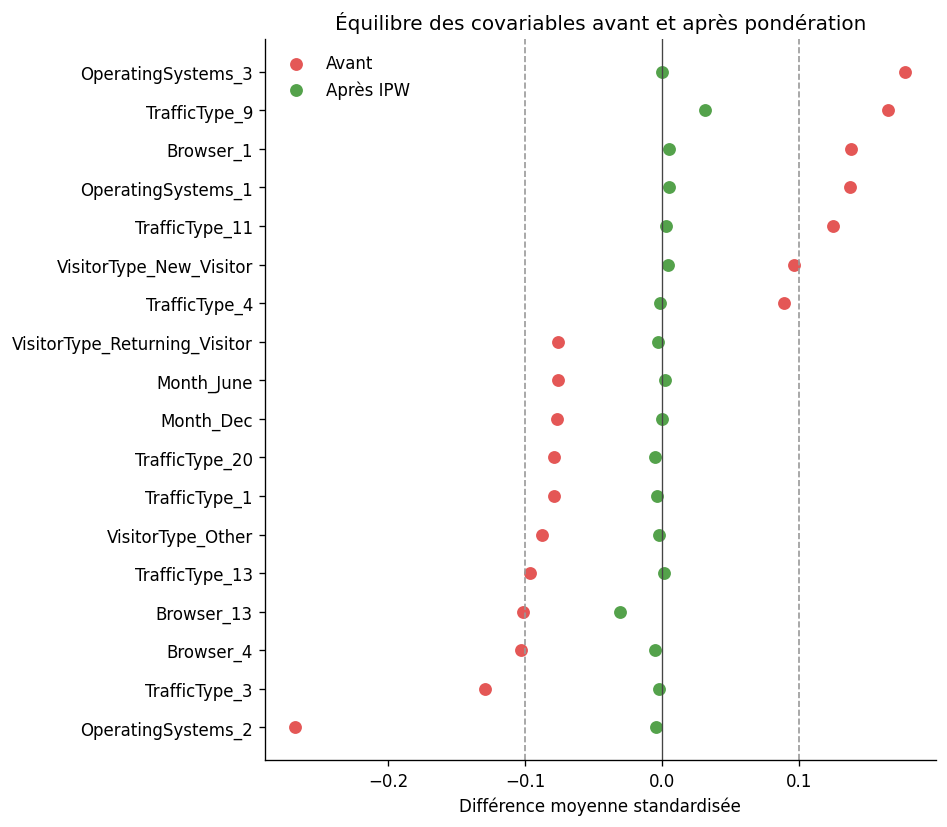

In [11]:
donnees_equilibre = predictions_principales["donnees"]
z = pd.get_dummies(
    donnees_equilibre[COVARIABLES_CATEGORIELLES],
    prefix=COVARIABLES_CATEGORIELLES,
    dtype=float,
)


def moyenne_ponderee(x, w):
    return np.average(x, weights=w)


def smd(x, pondere=False):
    x = np.asarray(x, dtype=float)
    traite = t == 1
    controle = ~traite
    if pondere:
        mt = moyenne_ponderee(x[traite], poids_stabilises[traite])
        mc = moyenne_ponderee(x[controle], poids_stabilises[controle])
        vt = moyenne_ponderee((x[traite] - mt) ** 2, poids_stabilises[traite])
        vc = moyenne_ponderee((x[controle] - mc) ** 2, poids_stabilises[controle])
    else:
        mt, mc = x[traite].mean(), x[controle].mean()
        vt, vc = x[traite].var(ddof=1), x[controle].var(ddof=1)
    denominateur = np.sqrt((vt + vc) / 2)
    return 0.0 if denominateur == 0 else (mt - mc) / denominateur


equilibre = pd.DataFrame(
    {
        "Avant": [smd(z[c], False) for c in z],
        "Après IPW": [smd(z[c], True) for c in z],
    },
    index=z.columns,
)

diagnostic_equilibre = pd.DataFrame({
    "Indicateur": [
        "SMD absolu maximal avant",
        "SMD absolu maximal après IPW",
        "Variables avec |SMD| > 0,10 avant",
        "Variables avec |SMD| > 0,10 après IPW",
    ],
    "Valeur": [
        equilibre["Avant"].abs().max(),
        equilibre["Après IPW"].abs().max(),
        int((equilibre["Avant"].abs() > 0.10).sum()),
        int((equilibre["Après IPW"].abs() > 0.10).sum()),
    ],
})
display(diagnostic_equilibre.round(3))

top = (
    equilibre.assign(max_abs=equilibre.abs().max(axis=1))
    .sort_values("max_abs", ascending=False)
    .head(18)
    .sort_values("Avant")
)
fig, ax = plt.subplots(figsize=(8, 7))
y_pos = np.arange(len(top))
ax.scatter(top["Avant"], y_pos, label="Avant", color="#E45756", s=45)
ax.scatter(top["Après IPW"], y_pos, label="Après IPW", color="#54A24B", s=45)
ax.axvline(-0.10, color="#999999", linestyle="--", linewidth=1)
ax.axvline(0.10, color="#999999", linestyle="--", linewidth=1)
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_yticks(y_pos, top.index)
ax.set_xlabel("Différence moyenne standardisée")
ax.set_title("Équilibre des covariables avant et après pondération")
ax.legend(frameon=False)
fig.tight_layout()
chemin = DOSSIER_FIGURES / "05_equilibre_covariables.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

equilibre.to_csv(DOSSIER_TABLEAUX / "03_equilibre_covariables.csv")

Le score varie d'environ 0,05 à 0,92. Seules neuf observations se trouvent sous 0,05 et aucune au-dessus de 0,95. Les tailles d'échantillon effectives restent proches des effectifs observés. Le SMD absolu maximal passe de **0,268** à **0,040**, et aucune indicatrice ne dépasse 0,10 après pondération. Le recouvrement et l'équilibre mesurés sont donc satisfaisants dans la population restreinte.

## 10. Résultats principaux

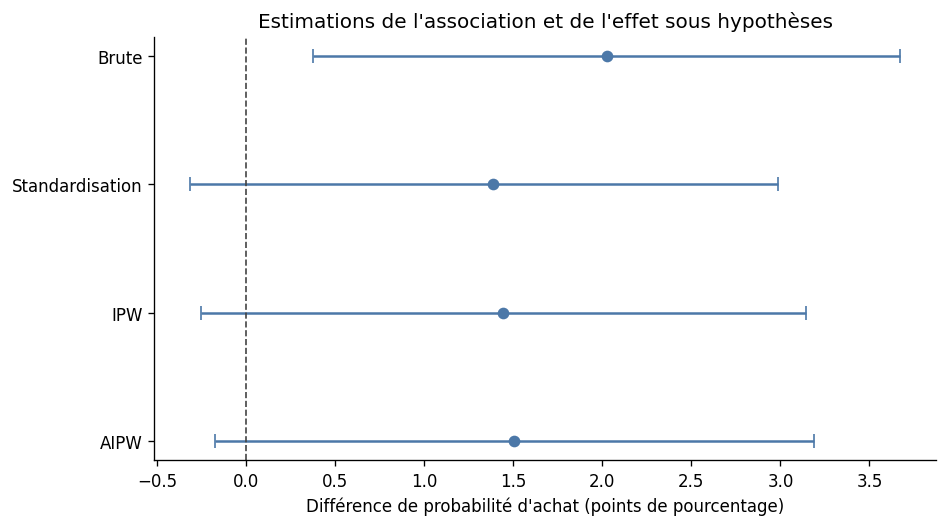

Moyenne potentielle AIPW sous weekend : 17.67 %
Moyenne potentielle AIPW sous semaine : 16.16 %


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
table_trace = resultats_principaux.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(table_trace))
estimations = table_trace["Estimation (points)"].to_numpy()
bas = table_trace["IC 95 % bas"].to_numpy()
haut = table_trace["IC 95 % haut"].to_numpy()

ax.errorbar(
    estimations,
    y_pos,
    xerr=[estimations - bas, haut - estimations],
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=4,
)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax.set_yticks(y_pos, table_trace["Méthode"])
ax.set_xlabel("Différence de probabilité d'achat (points de pourcentage)")
ax.set_title("Estimations de l'association et de l'effet sous hypothèses")
fig.tight_layout()
chemin = DOSSIER_FIGURES / "06_estimations_principales.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

print(
    "Moyenne potentielle AIPW sous weekend : "
    f"{100 * resume_estimation['mu1_aipw']:.2f} %"
)
print(
    "Moyenne potentielle AIPW sous semaine : "
    f"{100 * resume_estimation['mu0_aipw']:.2f} %"
)

La différence brute est de **2,03 points**. Après ajustement, les trois méthodes principales donnent des estimations comprises entre **1,38 et 1,51 point**.

L'AIPW estime une probabilité moyenne de 17,67 % sous weekend contre 16,16 % sous semaine, soit **+1,51 point de pourcentage**. Son intervalle à 95 % est **[-0,18 ; 3,19]** points et contient zéro.

Le signe est positif, mais les données restent compatibles avec une absence d'effet moyen. Le résultat ne permet donc pas d'affirmer que le weekend augmente causalement les achats.

## 11. Robustesse et sensibilité

Plusieurs choix sont modifiés : rôle de `TrafficType`, population complète avec un indicateur de jour spécial, retrait des doublons, restriction au support commun et modèles de nuisance par forêt aléatoire.

,Scénario,N,Estimation (points),IC 95 % bas,IC 95 % haut
0,"Principale : SpecialDay=0, avec trafic",11079,1.506,-0.176,3.188
1,Sans TrafficType,11079,2.233,0.535,3.931
2,Population complète + indicateur jour spécial,12330,1.193,-0.392,2.778
3,Sans doublons exacts,10956,1.199,-0.484,2.882
4,"Support commun [0,05 ; 0,95]",11070,1.555,-0.126,3.235
5,Forêt aléatoire pour les nuisances,11079,1.736,0.123,3.348


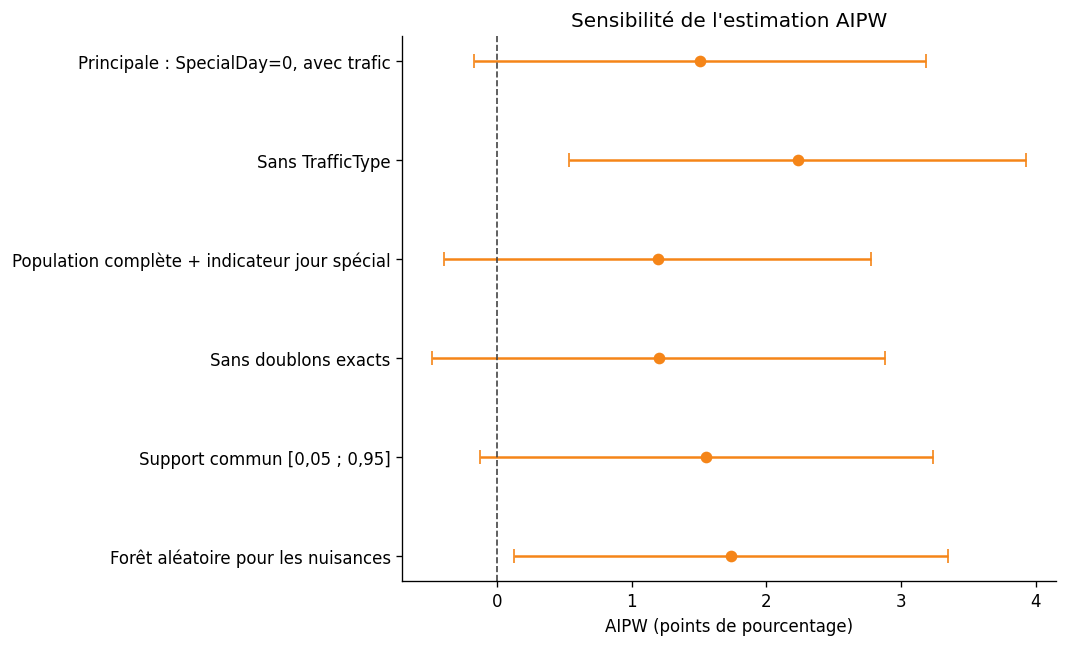

In [13]:
df_avec_indicateur = df.copy()
df_avec_indicateur["NearSpecialDay"] = df_avec_indicateur["SpecialDay"].gt(0).astype(int)


def resultat_aipw(
    donnees,
    covariables_categorielles,
    covariables_binaires=(),
    modele="logit",
    trim=None,
):
    pred = predictions_croisees(
        donnees,
        covariables_categorielles,
        covariables_binaires,
        modele,
    )
    masque = np.ones(len(pred["Y"]), dtype=bool)
    if trim is not None:
        masque = (pred["e"] >= trim[0]) & (pred["e"] <= trim[1])

    t_v = pred["T"][masque]
    y_v = pred["Y"][masque]
    e_v = pred["e"][masque]
    m1_v = pred["m1"][masque]
    m0_v = pred["m0"][masque]
    pseudo = (
        m1_v - m0_v
        + t_v * (y_v - m1_v) / e_v
        - (1 - t_v) * (y_v - m0_v) / (1 - e_v)
    )
    estimation = pseudo.mean()
    se = pseudo.std(ddof=1) / np.sqrt(len(pseudo))
    return {
        "N": len(pseudo),
        "Estimation (points)": 100 * estimation,
        "IC 95 % bas": 100 * (estimation - 1.96 * se),
        "IC 95 % haut": 100 * (estimation + 1.96 * se),
    }


scenarios = []

def ajouter_scenario(nom, *args, **kwargs):
    resultat = resultat_aipw(*args, **kwargs)
    scenarios.append({"Scénario": nom, **resultat})


ajouter_scenario(
    "Principale : SpecialDay=0, avec trafic",
    df_analyse,
    COVARIABLES_CATEGORIELLES,
)
ajouter_scenario(
    "Sans TrafficType",
    df_analyse,
    [c for c in COVARIABLES_CATEGORIELLES if c != "TrafficType"],
)
ajouter_scenario(
    "Population complète + indicateur jour spécial",
    df_avec_indicateur,
    COVARIABLES_CATEGORIELLES,
    ["NearSpecialDay"],
)
ajouter_scenario(
    "Sans doublons exacts",
    df_analyse.drop_duplicates().reset_index(drop=True),
    COVARIABLES_CATEGORIELLES,
)
ajouter_scenario(
    "Support commun [0,05 ; 0,95]",
    df_analyse,
    COVARIABLES_CATEGORIELLES,
    trim=(0.05, 0.95),
)
ajouter_scenario(
    "Forêt aléatoire pour les nuisances",
    df_analyse,
    COVARIABLES_CATEGORIELLES,
    modele="foret",
)

robustesse = pd.DataFrame(scenarios)
display(robustesse.round(3))
robustesse.to_csv(DOSSIER_TABLEAUX / "04_analyses_robustesse.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
table_trace = robustesse.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(table_trace))
est = table_trace["Estimation (points)"].to_numpy()
bas = table_trace["IC 95 % bas"].to_numpy()
haut = table_trace["IC 95 % haut"].to_numpy()
ax.errorbar(
    est, y_pos, xerr=[est - bas, haut - est], fmt="o",
    color="#F58518", ecolor="#F58518", capsize=4
)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax.set_yticks(y_pos, table_trace["Scénario"])
ax.set_xlabel("AIPW (points de pourcentage)")
ax.set_title("Sensibilité de l'estimation AIPW")
fig.tight_layout()
chemin = DOSSIER_FIGURES / "07_robustesse_aipw.png"
fig.savefig(chemin, dpi=180, bbox_inches="tight")
plt.show()

In [14]:
risque_weekend = resume_estimation["mu1_aipw"]
risque_semaine = resume_estimation["mu0_aipw"]
rapport_risques = risque_weekend / risque_semaine
e_value = rapport_risques + np.sqrt(rapport_risques * (rapport_risques - 1))

print(f"Rapport de risques AIPW : {rapport_risques:.3f}")
print(f"E-value du point estimé : {e_value:.3f}")
print("E-value de la borne de l'IC la plus proche de 1 : 1,000")

Rapport de risques AIPW : 1.093
E-value du point estimé : 1.412
E-value de la borne de l'IC la plus proche de 1 : 1,000


Les analyses restent positives, entre environ **1,20 et 2,23 points** avec la régression logistique, mais plusieurs intervalles contiennent zéro. Retirer `TrafficType` augmente l'estimation à 2,23 points, ce qui confirme que son statut causal est déterminant. La forêt aléatoire donne 1,74 point, proche de l'analyse principale.

L'E-value du point estimé est 1,41 : une confusion non observée d'association modérée avec l'exposition et le résultat pourrait suffire à expliquer le point estimé. Comme l'intervalle principal contient déjà zéro, l'E-value de sa borne est 1. Cette analyse renforce la prudence de la conclusion.

## 12. Interprétation et limites

### Interprétation

Dans les sessions hors proximité d'un jour spécial, le taux d'achat est plus élevé le weekend. Après ajustement sur les variables pré-session, l'estimation AIPW est de **+1,51 point de pourcentage**, mais son intervalle à 95 % contient zéro.

La conclusion la plus défendable est donc :

> Les données sont compatibles avec un faible contraste positif du weekend sur la probabilité d'achat, mais elles ne permettent pas d'établir un effet causal moyen différent de zéro.

### Limites principales

1. `Weekend` est une exposition calendaire, pas un traitement réellement assigné.
2. L'analyse conditionne sur l'existence d'une session et ne mesure pas le volume total des visites.
3. Promotions, prix, produits, campagne, heure exacte et intention préalable ne sont pas observés.
4. `TrafficType` peut être confondeur ou médiateur; les résultats changent selon son statut.
5. Le site et les codes de catégories sont anonymes, ce qui limite les connaissances du domaine.
6. La découverte causale dépend de regroupements, de tests (G^2) et d'hypothèses structurelles.
7. Les intervalles asymptotiques et le bootstrap ne corrigent pas la confusion non observée.
8. Le résultat ne se généralise pas automatiquement à d'autres sites ou périodes.

Ces limites sont centrales : un modèle statistique plus complexe ne peut pas remplacer une stratégie d'identification crédible.

## 13. Conclusion

Le projet a formulé une question causale précise, construit un DAG, utilisé FCI comme découverte exploratoire, défini un estimand et comparé plusieurs estimateurs.

L'association brute est de **+2,03 points** dans la population retenue. Les estimations ajustées principales se situent autour de **+1,5 point**. L'AIPW donne **+1,51 point**, avec un IC à 95 % de **[-0,18 ; 3,19]**.

Il n'est donc pas possible de conclure que le weekend cause une augmentation des achats. Le résultat est une estimation exploratoire, conditionnelle à des hypothèses fortes et utile surtout pour montrer comment le raisonnement causal modifie l'interprétation d'une association descriptive.

## 14. Reproductibilité

- Le CSV brut est lu depuis `02_data/raw/online_shoppers_intention.csv`.
- Son empreinte SHA-256 est vérifiée au chargement.
- Toutes les graines aléatoires utilisent `20260715`.
- Les modèles sont évalués par cinq plis stratifiés.
- Les figures sont exportées dans `04_outputs/figures/`.
- Les tableaux sont exportés dans `04_outputs/tableaux/`.
- Les dépendances sont consignées dans `requirements.txt`.

## Références

- Sakar, C. et Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset*. UCI Machine Learning Repository. DOI: `10.24432/C5F88Q`.
- Sakar, C. O. et al. (2019). *Real-time prediction of online shoppers' purchasing intention using multilayer perceptron and LSTM recurrent neural networks*. Neural Computing and Applications.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference*. Cambridge University Press.
- Rosenbaum, P. R. et Rubin, D. B. (1983). *The central role of the propensity score in observational studies for causal effects*. Biometrika.
- Spirtes, P., Glymour, C. et Scheines, R. (2000). *Causation, Prediction, and Search*. MIT Press.
- Bang, H. et Robins, J. M. (2005). *Doubly robust estimation in missing data and causal inference models*. Biometrics.
- VanderWeele, T. J. et Ding, P. (2017). *Sensitivity analysis in observational research: introducing the E-value*. Annals of Internal Medicine.